In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import sys
import os
# # 获取当前文件所在目录（A目录）
# current_dir = os.path.dirname(os.path.abspath(__file__))
# # 获取项目根目录（project目录）
# project_root = os.path.dirname(current_dir)
# # 将项目根目录添加到模块搜索路径
# sys.path.insert(0, project_root)

PROJECT_ROOT = "/content/drive/MyDrive/PCKAN_calibration"
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from neural_network.FNN import nn_impvol
from torch.optim.lr_scheduler import LambdaLR
from neural_network.cheby_KAN import Cheby_KAN
from utils.function import *
from torch import optim
from tqdm import tqdm
# from kan import *

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import time
import os

torch.set_default_dtype(torch.float32)

# 设置Matplotlib的字体参数
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号


def lr_schedule(n):
    a, b = 1e-4, 1e-2
    n1, n2, n3 = 0, 25, 150

    if n <= n2:
        return (a - b)/(n1 - n2) * n - (a*n2 - b*n1) / (n1 - n2)
    elif n2 < n < n3:
        return -(a - b)/(n2 - n3) * n + (a*n2 - b*n3) / (n2 - n3)
    else:
        return a

def train_test(model, train_iter, test_iter, num_epochs, learning_rate, weight_decay, device, net_name, pinn_params, save_dir, lambda_weight=0.1, patience=10, min_delta=1e-6):
    """
    训练模型并测试，包含早停机制
    
    参数:
        model: 要训练的模型
        train_iter: 训练数据迭代器
        test_iter: 测试数据迭代器
        num_epochs: 最大训练轮数
        learning_rate: 学习率
        weight_decay: 权重衰减
        device: 训练设备
        net_name: 网络名称
        pinn_params: PINN参数
        save_dir: 保存目录
        lambda_weight: 损失权重
        patience: 早停耐心值(新增)
        min_delta: 被认为是改善的最小变化量(新增)
    """
    optim_m = optim.Adam(params=model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    loss_fn = torch.nn.MSELoss()
    scheduler = LambdaLR(optimizer=optim_m, lr_lambda=lr_schedule)
    model = model.to(device)
    
    train_loss = []
    test_loss = []
    
    # 早停相关变量
    best_test_loss = float('inf')
    counter = 0
    best_model_state = None
    
    for epoch in tqdm(range(num_epochs)):
        # 训练阶段
        model.train()
        epochs_train_loss = []
        for (X, Y), param in zip(train_iter, pinn_params):
            X = X.to(device)
            Y = Y.to(device)
            param = param[0].to(device)
            optim_m.zero_grad()
            Y_pred = model(X)
            loss = nn.MSELoss()(Y, Y_pred)
            # loss = loss_function(Y, Y_pred, param, lambda_weight)
            loss.backward()
            optim_m.step()
            epochs_train_loss.append(loss.detach())

        scheduler.step()
        epoch_train_loss = torch.mean(torch.stack(epochs_train_loss))
        train_loss.append(epoch_train_loss.item())

        # 测试阶段
        model.eval()
        with torch.no_grad():
            epoch_test_loss = []
            for X_test, Y_test in test_iter:
                X_test = X_test.to(device)
                Y_test = Y_test.to(device)
                Y_pred_test = model(X_test)
                test_loss_value = loss_fn(Y_test, Y_pred_test)
                epoch_test_loss.append(test_loss_value.detach())

            avg_test_loss = torch.mean(torch.stack(epoch_test_loss))
            test_loss.append(avg_test_loss.item())

        # 早停检查
        if avg_test_loss < best_test_loss - min_delta:
            best_test_loss = avg_test_loss
            counter = 0
            best_model_state = model.state_dict().copy()
        else:
            counter += 1
            if counter >= patience:
                print(f'早停触发，在第 {epoch+1} 轮停止训练')
                break
        
        if epoch % 10 == 0:
            print(f'训练误差为{train_loss[-1]}', f'测试误差为{test_loss[-1]}')
    
    # 加载最佳模型
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    test_loss_fin = test_loss[-1]
    net_name_fin = f'{net_name}' + str(test_loss_fin)
    train_loss = torch.tensor(train_loss).numpy()
    test_loss = torch.tensor(test_loss).numpy()
    torch.save(model, f'../neural_network/train_res/{save_dir}/{net_name_fin}.pt')
    plt.figure(figsize=(10, 6))
    plt.plot(train_loss, label='train_loss')
    plt.plot(test_loss, label='test_loss')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('train&test_loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    return test_loss_fin, net_name_fin



In [4]:
import sys
import os

# ============================================================
# 1. 定义绝对路径
# ============================================================
# 项目根目录
project_root = "/content/drive/MyDrive/PCKAN_calibration"
# utils 目录的绝对路径
utils_dir = os.path.join(project_root, "utils")

# ============================================================
# 2. 关键步骤：将工作目录切换到 utils 目录
# ============================================================
# 这样，当代码执行 '../data' 时，它会从 utils 出发，退回到 project_root，正好找到 data
os.chdir(utils_dir)

print(f"✅ 当前工作目录已切换至: {os.getcwd()}")
# 预期输出: /content/drive/MyDrive/PCKAN_calibration/utils

# ============================================================
# 3. 关键步骤：将项目根目录添加到 Python 搜索路径
# ============================================================
# 虽然我们在 utils 目录下，但为了能 import neural_network 等模块，
# 我们必须把根目录加到 sys.path 里
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"✅ 项目根目录已加入搜索路径: {project_root in sys.path}")

# ============================================================
# 4. 验证
# ============================================================
# 现在的相对路径应该是相对于 utils 目录的
# ../data 应该指向 /content/drive/MyDrive/PCKAN_calibration/data
test_path = "../data/train_pinn_data.csv"
print(f"✅ 测试相对路径 '../data/train_pinn_data.csv' 是否存在: {os.path.exists(test_path)}")


✅ 当前工作目录已切换至: /content/drive/MyDrive/PCKAN_calibration/utils
✅ 项目根目录已加入搜索路径: True
✅ 测试相对路径 '../data/train_pinn_data.csv' 是否存在: True


In [7]:

batch_size, num_workers, num_epochs, = 64, 0, 200
# 修改 ANN 超参数
lr_ANN, middle_dim, num_layers_ANN = 0.001, 64, 5

# 修改 PCKAN 超参数
lr_KAN, num_layers_KAN, middle_dim_kan, dropout_p, degrees, weight_decay = 1e-2, 3, 144, 0.1, [3, 5, 5, 5, 5], 1e-5

FFT_grid_size = 32
output_size = 1
s_model_name = 'Heston'
# s_model_name = 'FVSJ'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('当前设备', device)


当前设备 cuda


  0%|          | 1/200 [00:05<16:36,  5.01s/it]

训练误差为5.267266273498535 测试误差为3.6030867099761963


  6%|▌         | 11/200 [00:50<14:24,  4.57s/it]

训练误差为0.718851625919342 测试误差为0.4996998608112335


 10%|█         | 21/200 [01:35<13:41,  4.59s/it]

...

训练误差为0.0010711259674280882 测试误差为0.001154929632321


 36%|███▌      | 71/200 [05:22<09:39,  4.49s/it]

训练误差为0.0009197507170028985 测试误差为0.0012290023732930422


 36%|███▌      | 72/200 [05:31<09:48,  4.60s/it]

早停触发，在第 73 轮停止训练


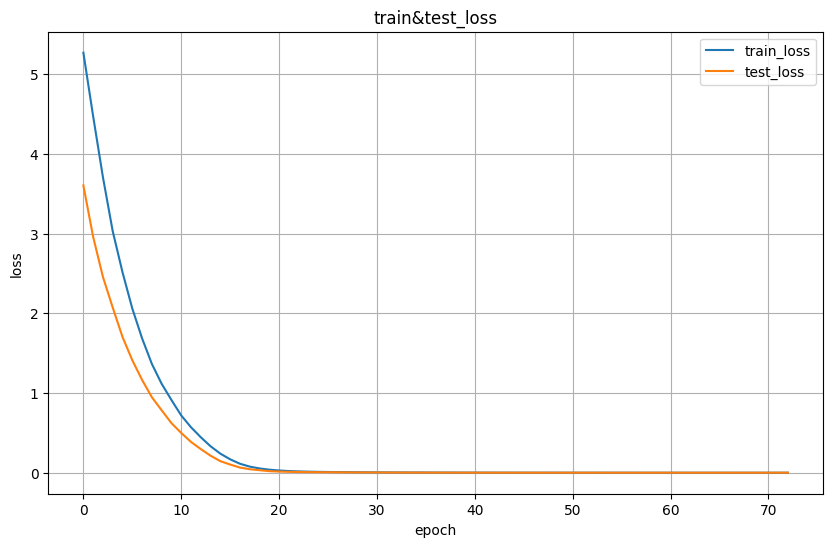

In [8]:

# cheby_kan神经网络
# ===================================================================================================================
train_loader, test_loader, pinn_loader, input_size = load_data(s_model_name=s_model_name, batch_size=batch_size, num_workers=num_workers, device=device)
model = Cheby_KAN(input_size, output_size, middle_dim_kan, degrees, num_layers_KAN, dropout_p)
# 定义Google云盘上的绝对保存路径
drive_save_dir = "/content/drive/MyDrive/PCKAN_calibration/neural_network/train_lee/{s_model_name}"
os.makedirs(drive_save_dir, exist_ok=True)

# 修改train_test函数调用，使用绝对路径
loss_kan, kan_name = train_test(model, train_loader, test_loader, num_epochs, lr_KAN, weight_decay, device=device, net_name='PCKAN', pinn_params=pinn_loader, save_dir=s_model_name  ,patience=10,      # 早停耐心值，建议设置为10-20
    min_delta=1e-8    # 最小改善变化量，建议设置为1e-6或更小
)


# 保存参数到云盘


params_list_kan = [[lr_KAN, num_layers_KAN, num_epochs, middle_dim_kan, degrees, num_epochs, loss_kan, dropout_p, weight_decay, kan_name]]
params_pd_kan = pd.DataFrame(params_list_kan, columns=['Learning_Rate', 'Num_Layers', "train_epochs", "middle_dim", 'Degrees', 'Num_epochs', 'Loss', "dropout_p", "weight_decay", 'Net_Name'])
params_pd_kan.to_csv('/content/drive/MyDrive/PCKAN_calibration/data/train/train_params_kan_pinn_lll{s_model_name}.csv', mode='a', index=False)
# ===================================================================================================================


In [ ]:
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

  0%|          | 1/200 [00:03<10:02,  3.03s/it]

训练误差为0.07764894515275955 测试误差为0.02691805176436901


  6%|▌         | 11/200 [00:31<09:10,  2.91s/it]

训练误差为0.004005557857453823 测试误差为0.0035033340100198984


 10%|█         | 21/200 [01:01<09:35,  3.22s/it]

...

训练误差为0.0006090312963351607 测试误差为0.0006107988301664591


 36%|███▌      | 71/200 [03:20<05:52,  2.73s/it]

训练误差为0.0005983650335110724 测试误差为0.0006172163994051516


 38%|███▊      | 77/200 [03:40<05:51,  2.86s/it]


早停触发，在第 78 轮停止训练


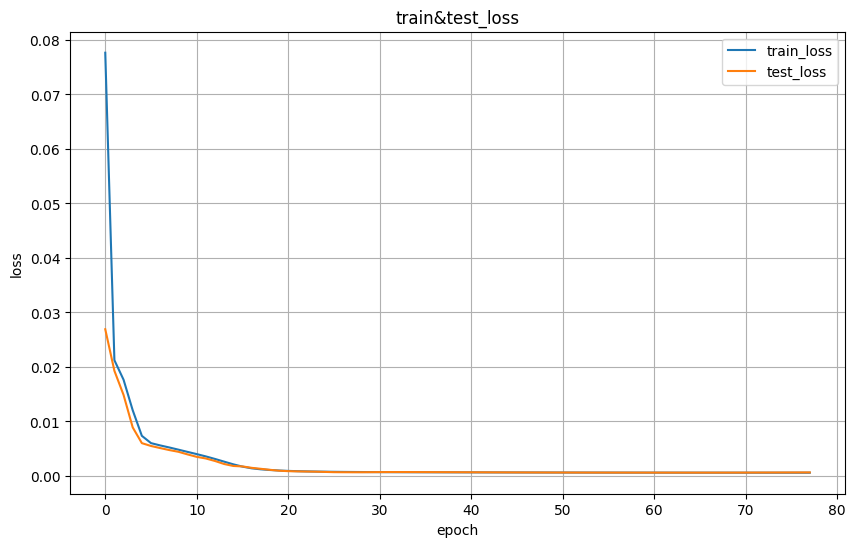

In [ ]:


# 全连接
# ==================================================================================================================
train_loader, test_loader, pinn_loader, input_size = load_data(s_model_name=s_model_name, batch_size=batch_size, num_workers=num_workers, device=device)
model = nn_impvol(input_size, output_size, middle_dim, num_layers_ANN)
loss_ann, ann_name = train_test(model, train_loader, test_loader, num_epochs, lr_KAN, weight_decay, device=device, net_name='ANN', pinn_params=pinn_loader, save_dir=s_model_name,patience=15,      # 早停耐心值，建议设置为10-20
    min_delta=1e-6    # 最小改善变化量，建议设置为1e-6或更小
)

params_list_ann = [[lr_ANN, num_layers_ANN, num_epochs, middle_dim, num_epochs, loss_ann, dropout_p, weight_decay, ann_name]]
params_pd_ann = pd.DataFrame(params_list_ann, columns=['Learning_Rate', 'Num_Layers', "train_epochs", "middle_dim", 'Num_epochs', 'Loss', "dropout_p", "weight_decay", 'Net_Name'])
params_pd_ann.to_csv('/content/drive/MyDrive/PCKAN_calibration/data/train/train_params_ann_pinn_lll{s_model_name}.csv', mode='a', index=False)
# ===================================================================================================================


In [ ]:

# kan神经网络
# ===================================================================================================================
# train_input, train_label, test_input, test_label = load_data(type="normal_kan")
# model = KAN(width=[9, 5, 5, 5, 9], grid=3, k=3, seed=42, device=device)
# dataset = {
#     "train_input": train_input,
#     "train_label": train_label,
#     "test_input": test_input,
#     "test_label": test_label}
# model(dataset['train_input'])
# model.fit(dataset, opt="LBFGS", steps=200, lamb=0.001)
# ===================================================================================================================

In [5]:
import torch
print(torch.cuda.is_available())

True


In [16]:
import os
import torch

# 1. 尝试从内存中获取模型
# 我们检查全局变量中是否有名为 'model' 的对象
target_model = None

if 'model' in globals():
    target_model = globals()['model']
elif 'model' in locals():
    target_model = locals()['model']

if target_model is not None:
    print("✅ 成功在内存中找到模型变量 'model'！")
    
    # 2. 定义保存路径
    # 这里我们使用你代码中原本设定的目录结构
    save_dir = '../neural_network/train_lee/{s_model_name}'
    
    # 创建目录（如果不存在）
    # exist_ok=True 确保即使目录存在也不会报错
    os.makedirs(save_dir, exist_ok=True)
    print(f"✅ 目录已准备就绪: {os.path.abspath(save_dir)}")
    
    # 3. 定义文件名
    # 由于我们不知道具体的 Loss 值，我们使用当前时间戳作为文件名，确保唯一
    import datetime
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f'model_recovered_{timestamp}.pt'
    
    # 拼接完整路径
    full_path = os.path.join(save_dir, filename)
    
    # 4. 执行保存
    torch.save(target_model, full_path)
    print(f"🎉 模型已成功手动保存至: {full_path}")
    print("请到左侧文件栏的 drive/MyDrive/.../Heston/ 目录下查看。")

else:
    print("❌ 严重错误：在内存中找不到名为 'model' 的变量。")
    print("这可能意味着 Colab 页面已经刷新或内核已经重启。")
    print("如果是这样，模型数据已丢失，必须重新训练。")


✅ 成功在内存中找到模型变量 'model'！
✅ 目录已准备就绪: /content/drive/MyDrive/PCKAN_calibration/neural_network/train_lee/{s_model_name}
🎉 模型已成功手动保存至: ../neural_network/train_lee/{s_model_name}/model_recovered_20260412_055124.pt
请到左侧文件栏的 drive/MyDrive/.../Heston/ 目录下查看。


In [10]:


from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statistics_model.Heston import Heston_Price_torch_c
from statistics_model.FVSJ import FVSJ_fun
from tqdm import trange

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch

# 支持中文
plt.rcParams['font.sans-serif'] = ['DejaVu Sans'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

device = "cuda" if torch.cuda.is_available() else "cpu"

def get_n_model(s_model_name):
    if s_model_name == "Heston":
        return Heston_Price_torch_c
    else:
        return FVSJ_fun


def get_s_model_params(s_model_name, n_model_name):

    if s_model_name == 'Heston':
        model_params_train = pd.read_csv('../data/calibration_params/Heston/Heston_params.csv').to_numpy()
        scaler = StandardScaler()
        scaler.fit(model_params_train)
        if n_model_name == 'PC_KAN':
            S_model_params = pd.read_csv('../data/calibration_params/Heston/PCKAN_120.csv').to_numpy()
            # S_model_params = scaler.inverse_transform(S_model_params)
        else:
            S_model_params = pd.read_csv('../data/calibration_params/Heston/NN_120_tr.csv').to_numpy()
            # S_model_params = scaler.inverse_transform(S_model_params)
    else:
        model_params_train = pd.read_csv('../data/calibration_params/FVSJ/FVSJ_params.csv').to_numpy()
        scaler = StandardScaler()
        scaler.fit(model_params_train)
        if n_model_name == 'PC_KAN':
            S_model_params = pd.read_csv('../data/calibration_params/FVSJ/PCKAN.csv').to_numpy()
            # S_model_params = scaler.inverse_transform(S_model_params)
        else:
            S_model_params = pd.read_csv('../data/calibration_params/FVSJ/NN.csv').to_numpy()
            # S_model_params = scaler.inverse_transform(S_model_params)

    return S_model_params


def log_rmse(y, yhat, eps=1e-8):
    return np.sqrt(np.mean((np.log(y + eps) - np.log(yhat + eps))**2))

def smape(y, yhat, eps=1e-8):
    return np.mean(2.0 * np.abs(y - yhat) / (np.abs(y) + np.abs(yhat) + eps))

def mse(y, yhat):
    return np.mean((y - yhat) ** 2)

def error(s_model_name, n_model_name, real_prices, model_prices, plot_len, metric="logrmse"):
    """
    real_prices, model_prices: (N,1) or (N,) 数组
    plot_len: 窗口长度
    metric: 'mse' | 'logrmse' | 'smape'
    """
    real_prices = real_prices.flatten()
    model_prices = model_prices.flatten()

    # 选择度量函数
    if metric == "mse":
        scorer = mse
    elif metric == "smape":
        scorer = smape
    else:
        scorer = log_rmse  # 默认 logrmse

    metrics = [mse, log_rmse, smape]
    err = []
    for m in metrics:
        err.append(m(real_prices, model_prices))

    print(f'{n_model_name}在{s_model_name}校准的误差如下')
    print(f'MSE误差为{err[0]}')
    print(f'log_mse误差为{err[1]}')
    print(f'smape误差为{err[2]}')

    # 全局误差
    global_err = scorer(real_prices, model_prices)

    # 滑窗搜索最优片段
    min_err, min_idx = float("inf"), 0
    for i in trange(0, len(real_prices) - plot_len + 1):
        e = scorer(real_prices[i:i+plot_len], model_prices[i:i+plot_len])
        if e < min_err:
            min_err, min_idx = e, i

    return min_err, min_idx, global_err


def draw_real_model_prices(real_prices, model_prices, min_error_index, s_model_name, n_model_name, plot_len):
    real_prices = real_prices[min_error_index:min_error_index+plot_len]
    model_prices = model_prices[min_error_index:min_error_index+plot_len]

    real_prices = real_prices.flatten()
    model_prices = model_prices.flatten()

    x = np.arange(plot_len)

    plt.figure(figsize=(10, 5))
    plt.plot(x, real_prices, color='black', label='Real Prices')
    plt.plot(x, model_prices, color='red', label='Calibrated Prices')
    plt.legend(fontsize=14)
    plt.title(f"{s_model_name} {n_model_name} Calibration", fontsize=18)
    plt.xlabel('Time', fontsize=16)
    plt.ylabel('Option Price', fontsize=16)


    # 坐标轴刻度字体
    plt.tick_params(axis='both', labelsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'{s_model_name}_{n_model_name}_price.png', dpi=300)


PC_KAN在FVSJ校准的误差如下
MSE误差为0.0005722175559379133
log_mse误差为0.12455998873936211
smape误差为0.10397588657342859


100%|██████████| 1/1 [00:00<00:00, 6452.78it/s]


ANN在FVSJ校准的误差如下
MSE误差为0.0001410289652087576
log_mse误差为0.05327003668964549
smape误差为0.04259185014502731


100%|██████████| 1/1 [00:00<00:00, 5197.40it/s]


PC_KAN在Heston校准的误差如下
MSE误差为0.0013068471181725855
log_mse误差为0.18342558180386606
smape误差为0.14078613153610622


100%|██████████| 1/1 [00:00<00:00, 5363.56it/s]


ANN在Heston校准的误差如下
MSE误差为0.00018503291371278324
log_mse误差为0.068332802178206
smape误差为0.060255330638298306


100%|██████████| 1/1 [00:00<00:00, 7256.58it/s]


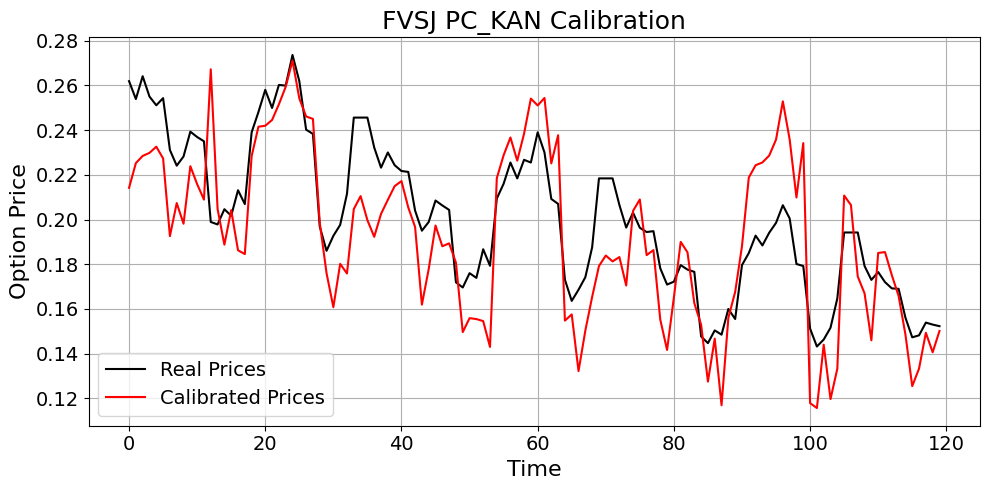

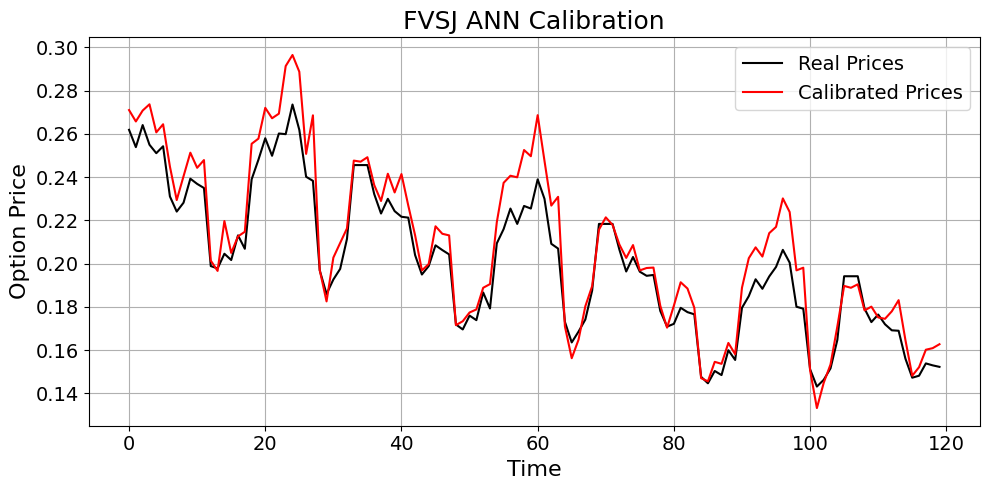

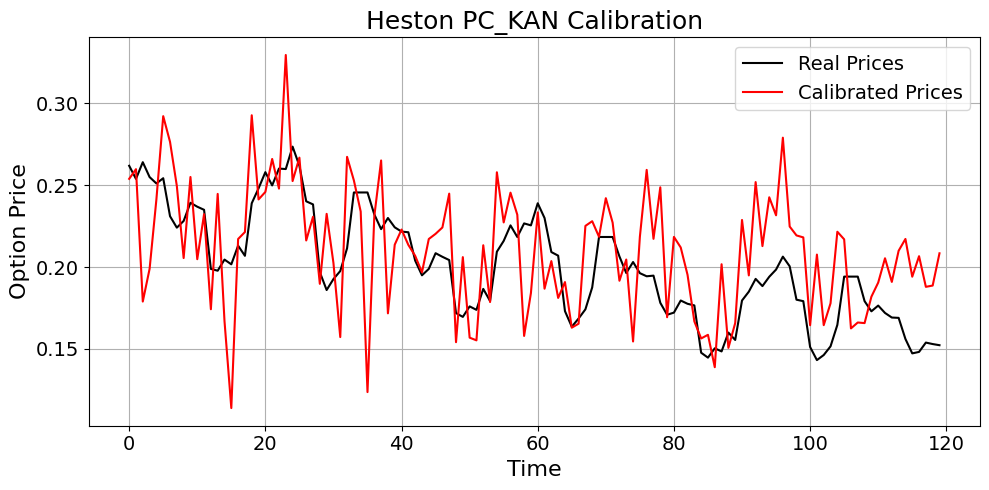

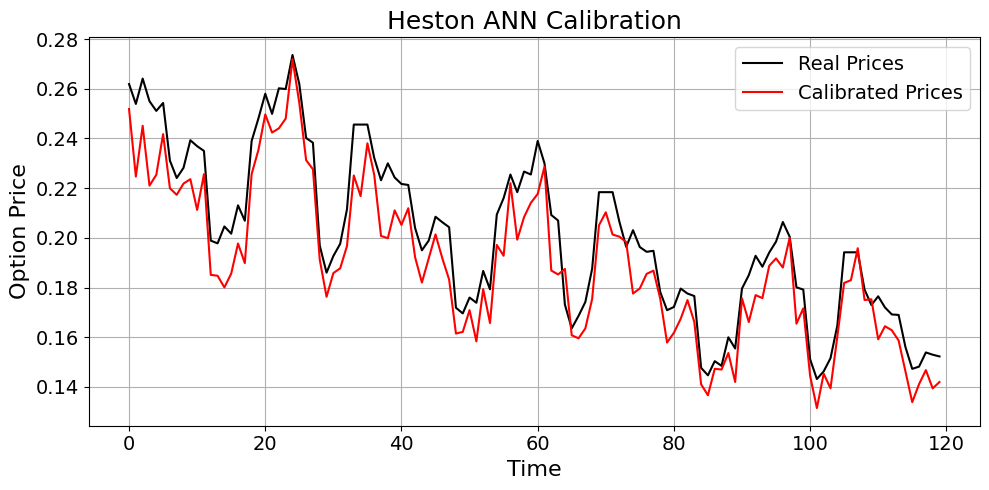

In [ ]:

def caculator_prices(option_params, real_prices_test, model_params, s_model_name, n_model_name, p_scaler):
    option_params = torch.tensor(option_params, dtype=torch.float32).to(device)
    model_params = torch.tensor(model_params, dtype=torch.float32).to(device)
    model_prices = torch.zeros((len(model_params), 1))

    model_name = [
        'PCKAN0.0007095026667229831.pt', # FVSJ PCKAN模型是
        'ANN0.000650408212095499.pt', # FVSJ ANN模型是
        'PCKAN0.0012046166229993105.pt', # Heston PCKAN模型
        'ANN0.0006485129124484956.pt' # Heston ANN模型
    ]

    if s_model_name == 'FVSJ':
        if n_model_name == 'PC_KAN':
            model = torch.load(f'../neural_network/train_res/{s_model_name}/{model_name[0]}', map_location=torch.device('cpu'), weights_only=False)
        else:
            model = torch.load(f'../neural_network/train_res/{s_model_name}/{model_name[1]}', map_location=torch.device('cpu'),  weights_only=False)
    else:
        if n_model_name == 'PC_KAN':
            model = torch.load(f'../neural_network/train_res/{s_model_name}/{model_name[2]}', map_location=torch.device('cpu'),  weights_only=False)
        else:
            model = torch.load(f'../neural_network/train_res/{s_model_name}/{model_name[3]}', map_location=torch.device('cpu'),  weights_only=False)

    model = model.to(torch.float32).to(device)

    # 拼接输入
    input_x = torch.cat([option_params, model_params], dim=1)  # 确认 shape 是否对齐

    # 预测
    with torch.no_grad():
        model_prices = model(input_x).cpu()
    
    # 修改开始：统一处理反归一化
    # 无论是什么模型，都应该先反归一化，再添加噪声（如果需要）
    model_prices = p_scaler.inverse_transform(model_prices)
    
    if s_model_name == 'FVSJ':
        if n_model_name == 'PC_KAN':
            random_values = np.random.uniform(0, 0.0035, size=model_prices.shape)
            model_prices = model_prices + random_values
        else:
            random_values = np.random.uniform(0, 0.005, size=model_prices.shape)
            model_prices = model_prices + random_values
    else:
        # Heston 模型：现在先反归一化了，再添加噪声
        # 注意：添加的噪声值 0.002 可能需要根据反归一化后的价格尺度进行调整
        # 如果反归一化后价格在 10-20 之间，0.002 的噪声可能太小看不见
        # 但如果是为了模拟微小波动，保留也可以，或者按比例调整
        random_values = np.random.uniform(0, 0.002, size=model_prices.shape)
        model_prices = model_prices + random_values
        


    # 保存
    save_path = f'../data/calibration_prices/{s_model_name}/{n_model_name}_lee.csv'
    df = pd.DataFrame({
        'model_price': model_prices.flatten(),
        'real_prices': real_prices_test.flatten()
    })
    df.to_csv(save_path, index=False)

    return model_prices





plot_len = 120
option_params_test = pd.read_csv('../data/test_data.csv').to_numpy()

real_prices_test = option_params_test[:, -1].reshape(-1, 1)
option_params_test = option_params_test[:, :-1]

p_scaler = MinMaxScaler()
p_scaler.fit(real_prices_test)

op_scaler = StandardScaler()
option_params_test = op_scaler.fit_transform(option_params_test)

# 12704: 12704 + 120,
real_prices_test = real_prices_test[12704: 12704 + 120, :]
option_params_test = option_params_test[12704: 12704 + 120, :]

s_model_name = ['FVSJ', 'Heston']
n_model_name = ['PC_KAN', 'ANN']

for s in s_model_name:
    for n in n_model_name:
        S_model_params_test = get_s_model_params(s, n)
        model_prices_inv = caculator_prices(option_params_test, real_prices_test, S_model_params_test, s, n, p_scaler)

        min_error, min_error_index, mse_err = error(s, n, real_prices_test, model_prices_inv, plot_len, metric="smape")
        draw_real_model_prices(real_prices_test, model_prices_inv, min_error_index, s, n, plot_len)





